# RI Extraction - Additional Operation For Parasite Medium Filtering

In [1]:
# Import libraries:
import numpy as np
from PIL import Image 
import tiffile as tf
import scipy as sp
import os
import matplotlib.pyplot as plt

# Filter
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu
from skimage.filters import threshold_multiotsu

# I/O Allocation

In [2]:
# Path Variables:
repo_path = "/Users/caoze/Documents/GitHub/Photon-Transport-Simulation/"     # Replace with repository path
access_address = "data/raw/"         

# Helpers:
def output_address(subfolder="data/", repository=repo_path):
    out_path = f"{repository}{subfolder}"
    return out_path

def modified_output_address(file_name, tag):
    name_part = file_name.split(".")[0]
    new_name = f"{name_part}_{tag}.mat"
    return new_name

Load in the data as a numpy matrix

In [3]:
# Accessing the file:
file_name = "test_para.tif"     # Replace with actual file name
access_path = f"{repo_path}{access_address}{file_name}"
print(f"Accessing: {access_path}, make sure this is correct.")

Accessing: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/raw/test_para.tif, make sure this is correct.


In [4]:
# Try to load raw file:
if(file_name.split(".")[-1] == "tiff" or file_name.split(".")[-1] == "tif"):
    raw = tf.imread(access_path)
    print(f"TIFF loaded successfully!")
elif(file_name.split(".")[-1] == "jpeg" or file_name.split(".")[-1] == "jpg" or file_name.split(".")[-1] == "png"):
    raw = Image.open(access_path)
    print(f"Image loaded successfully!")
else:
    raise ValueError("Unsupported file format. Please use TIFF, JPEG, or PNG.")

TIFF loaded successfully!


Raw file information:
Shape: (214, 184)
Data type: uint16


Refractive Index (RI) matrix information:
Shape: (214, 184)
Data type: float64
Min value: 1.3275, Max value: 1.4508


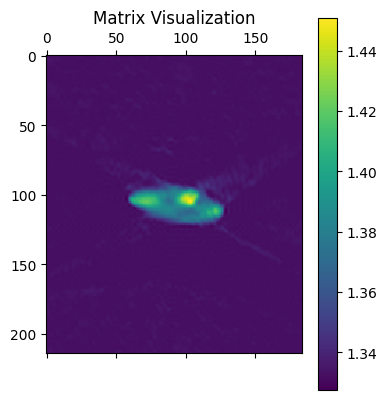

In [5]:
# Convert to numpy array (already a numpy matrix)
try:
    raw_mat = np.array(raw)
except Exception as e:
    print(f"Error converting image to numpy array: {e}")
    raise

# Print raw file information:
print("Raw file information:")
print(f"Shape: {raw_mat.shape}")
print(f"Data type: {raw_mat.dtype}")
print("\n")

# Fix RI values of raw Fiji Output to be in the range of 1.0 to 2.0:
ri_mat = raw_mat / 10000
print("Refractive Index (RI) matrix information:")
print(f"Shape: {ri_mat.shape}")
print(f"Data type: {ri_mat.dtype}")
print(f"Min value: {ri_mat.min()}, Max value: {ri_mat.max()}")

# Plot matrix out to verify
plt.matshow(ri_mat) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

# Filtering

In [6]:
# Fast Fourier Filtering Helper
def fourier_lowpass(ri, sigma=40):  # sigma - width of Gaussian in frequency space
    F = np.fft.fft2(ri)             # Fast Fourier
    F_shift = np.fft.fftshift(F)    # Find Center

    rows, cols = ri.shape
    crow, ccol = rows // 2, cols // 2

    #Create Frequency Axis and Grids
    u = np.arange(rows) - crow 
    v = np.arange(cols) - ccol
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)    # Radial distance

    # Gaussian Filter
    H = np.exp(-(D**2) / (2 * sigma**2))    

    # Apply filter
    F_filtered = F_shift * H
    F_ishift = np.fft.ifftshift(F_filtered) # Shift back
    ri_filtered = np.fft.ifft2(F_ishift)    # Reverse FFT

    return np.real(ri_filtered)

# Evaluate Fourier Helper 
def evaluate_filtering(ri, ri_filtered):
    F_orig = np.fft.fftshift(np.fft.fft2(ri))
    F_filt = np.fft.fftshift(np.fft.fft2(ri_filtered))

    E_orig = np.sum(np.abs(F_orig)**2)
    E_filt = np.sum(np.abs(F_filt)**2)

    diff = ri - ri_filtered

    print("Energy loss:", (E_orig - E_filt)/E_orig)
    print("Mean abs change:", np.mean(np.abs(diff)))
    print("Max abs change:", np.max(np.abs(diff)))
    print("Peak RI before:", ri.max())
    print("Peak RI after:", ri_filtered.max())

# Removing Speckle Noise:
def null_neighbor_trimming(array):
    # For each pixel, if more than 2 neighbors in (left, right, up or down) are 0, set it to 0 as well. This is to remove speckle noise.
    for i in range(1, array.shape[0]-1):
        for j in range(1, array.shape[1]-1):
            if array[i,j] != 0:
                neighbors = [array[i-1,j], array[i+1,j], array[i,j-1], array[i,j+1]]
                if neighbors.count(0) > 2:
                    array[i,j] = 0
    return array 


Apply Fourier Filtering
Apply Median Filter
Background Suppression
Speckle Removal


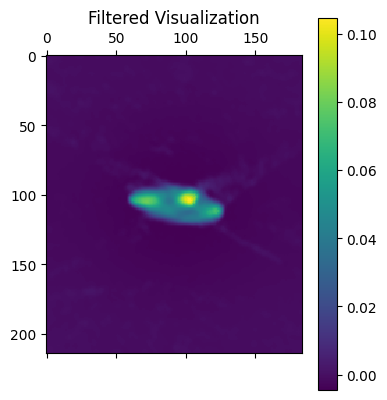

Energy loss: 0.9999498254735689
Mean abs change: 1.3346275015237707
Max abs change: 1.3520967246407147
Peak RI before: 1.4508
Peak RI after: 0.10455946135639138


In [7]:
# Fourier Filter
print("Apply Fourier Filtering")
sigma = ri_mat.shape[0] // 8
fourier_mat = fourier_lowpass(ri_mat, sigma) # Lower sigma = more filtering

# Median Filter
print("Apply Median Filter")
ri_med = median_filter(fourier_mat, size=3) # Increase size for greater strength

# Background Suppression - Gaussian Filter
print("Background Suppression")
background = gaussian_filter(ri_med, sigma=50)
ri_flat = ri_med - background

# Speckle Removal:
print("Speckle Removal")
filtered_ri = null_neighbor_trimming(ri_flat)

# Plot
plt.matshow(filtered_ri) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Filtered Visualization")
plt.show() 

# Evaluate filter:
evaluate_filtering(ri_mat, ri_flat)

Apply 2 Thresholding of RI & Extract 2 Layered Masks using multi-otsu algorithm

Binary matrix created with threshold 0.023842097125411306.
Shape: (214, 184)
Unique values in binary matrix: [0 1]


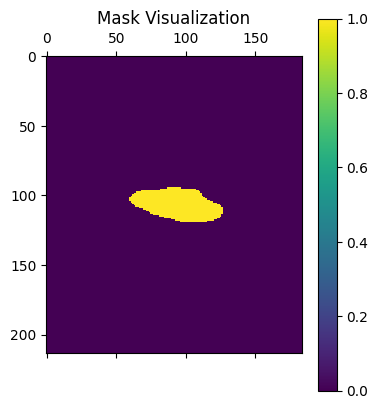

In [8]:
# Apply RI Threshold to mask the image:
ri_threshold = threshold_otsu(ri_flat)  

# Create binary matrix based on RI threshold
binary_mat = np.where(ri_flat >= ri_threshold, 1, 0)
print(f"Binary matrix created with threshold {ri_threshold}.")
print(f"Shape: {binary_mat.shape}")
print(f"Unique values in binary matrix: {np.unique(binary_mat)}")

plt.matshow(binary_mat) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Mask Visualization")
plt.show() 

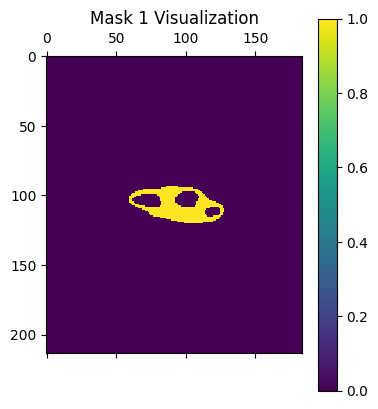

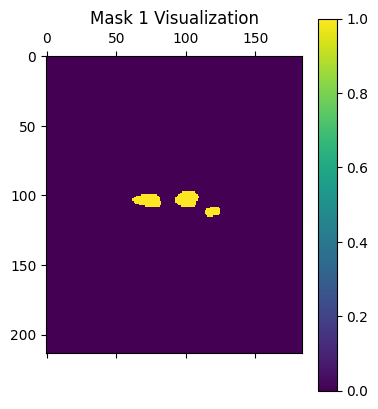

In [9]:
# Apply multi-otsu to find 3 classes
thresholds_multi = threshold_multiotsu(ri_flat, classes=3)
regions = np.digitize(ri_flat, bins=thresholds_multi)

# Create 2 separate masks
mask1 = (regions == 1)
mask2 = (regions == 2) 
# regions == 0 would be Backgroud/Dark
# regions == 1 would be Mid-gray
# regions == 2 would be foreground/Bright

plt.matshow(mask1) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Mask 1 Visualization")
plt.show() 

plt.matshow(mask2) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Mask 1 Visualization")
plt.show() 

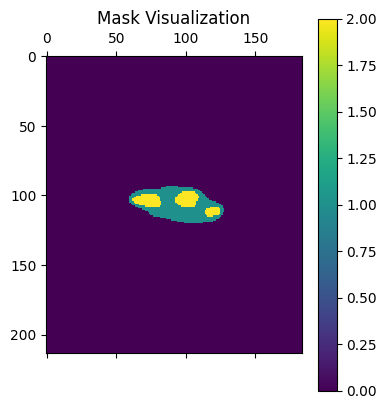

In [10]:
# Overlay the 2 masks to label for 2 fair regions of interest:
overlay_mask = np.zeros_like(ri_flat)
overlay_mask[mask1] = 1
overlay_mask[mask2] = 2

plt.matshow(overlay_mask) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Mask Visualization")
plt.show() 

Masked RI matrix created by overlaying binary mask onto RI matrix.

Shape: (214, 184)
Data type: float64
Max value: 1.4013


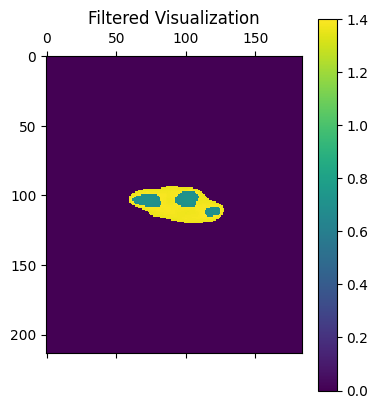

In [11]:
# Makes Matrices are dimensionally compatible
if ri_mat.shape != mask1.shape:
    raise ValueError("RI matrix and binary matrix have different shapes. Please check the input data.")

# Apply binary mask to RI matrix
masked_ri_mat = mask1 * ri_mat + mask2 * 0.5 * ri_mat

# Print masked RI matrix information:
print("Masked RI matrix created by overlaying binary mask onto RI matrix.\n")
print(f"Shape: {masked_ri_mat.shape}")
print(f"Data type: {masked_ri_mat.dtype}")
print(f"Max value: {masked_ri_mat.max()}")

# Show Matrix
plt.matshow(masked_ri_mat) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Filtered Visualization")
plt.show() 

# Crop Into Square For Operation Convenience

In [12]:
# Identify truncating borders.

# 1 Locate center of the body in the masked RI matrix
def body_center (array):
    center_x = 0
    center_y = 0
    i_count, j_count = 0, 0
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            if array[i,j] > 0: # Assuming the body presence
                center_y += i
                i_count += 1
                center_x += j 
                j_count += 1
                
    center_y /= i_count
    center_x /= j_count
    return int(center_x), int(center_y)

cent = body_center(masked_ri_mat)
print(f"Body Center at {cent}")

# Truncate Boundaries
def trunk_bound(size, center):
    cut = size/2
    start_x = int(center[0] - cut)
    end_x = int(center[0] + cut)
    start_y = int(center[1] - cut)
    end_y = int(center[1] + cut)
    return (start_x, end_x), (start_y, end_y)

trunk_x, trunk_y = trunk_bound(150, cent)
print(f"Truncating x-axis from {trunk_x[0]} to {trunk_x[1]}")
print(f"Truncating y-axis from {trunk_y[0]} to {trunk_y[1]}")


Body Center at (94, 106)
Truncating x-axis from 19 to 169
Truncating y-axis from 31 to 181


Truncated RI matrix shape: (150, 150)


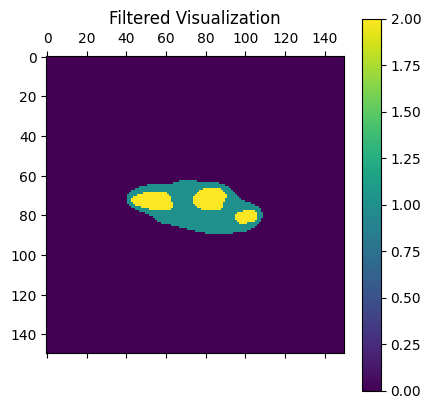

In [13]:
# Truncate Into Square of Desired Size
truncated_overlay = overlay_mask[trunk_y[0]:trunk_y[1], trunk_x[0]:trunk_x[1]]
print(f"Truncated RI matrix shape: {truncated_overlay.shape}")

# Show Matrix
plt.matshow(truncated_overlay) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Filtered Visualization")
plt.show() 

# Saving Labels

In [14]:
# Save the label matrix as .mat file for later use in simulation:
out_folder = "data/media_label/"
output_path = output_address(out_folder, repo_path)
output_name = modified_output_address(file_name=file_name, tag="label")

# Save
try:
    sp.io.savemat(f"{output_path}{output_name}", {"masked_ri": truncated_overlay})
    print(f"Extracted RI matrix saved successfully at {output_path}{output_name}!")
except Exception as e:
    print(f"Error saving extracted RI matrix: {e}")
    raise



Extracted RI matrix saved successfully at /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/media_label/test_para_label.mat!
